# OpenML Task 363629 — Fine-tuning TabPFN v3

Compares vanilla TabPFN v3 vs fine-tuned TabPFN v3 on OpenML task 363629.

**Fine-tuning approach (using custom `TabPFNFinetuner` from `finetuning_engine`):**
1. Each epoch randomly splits training data into a context (support) set and a query set.
2. The model sees all rows as features, only context labels — same meta-learning setup as pre-training.
3. CrossEntropyLoss is computed on query predictions.
4. Gradients update the underlying TabPFN transformer weights.

**`TabPFNFinetuner` key parameters:**
| Parameter | Role |
|---|---|
| `epochs` | Number of fine-tuning epochs |
| `learning_rate` | AdamW LR (small values, e.g. 1e-5 to 1e-4, recommended) |
| `query_ratio` | Fraction of training samples used as query set per epoch |
| `patience` | Early-stopping patience (epochs without val improvement) |
| `grad_clip` | Max gradient norm for clipping (0 = disabled) |
| `freeze_feature_attn` | Freeze feature-attention sub-modules |
| `freeze_row_attn` | Freeze row-attention sub-modules |
| `freeze_decoder` | Freeze the output decoder head |
| `warmup_proportion` | Fraction of steps used for LR warmup |

In [2]:
import sys
sys.path.insert(0, "..")

import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

## 1. Load OpenML task 363629

In [3]:
TASK_ID = 363629

task = openml.tasks.get_task(TASK_ID)
dataset = task.get_dataset()
X_df, y_series, _, _ = dataset.get_data(target=dataset.default_target_attribute)

# Encode categoricals and target
X_df = X_df.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)) if col.dtype == object else col)
X = X_df.values.astype(np.float32)
# Replace NaNs with column means
col_means = np.nanmean(X, axis=0)
nan_mask = np.isnan(X)
X[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

le = LabelEncoder()
y = le.fit_transform(y_series.astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Dataset: {dataset.name}")
print(f"Features: {X.shape[1]} | Classes: {len(le.classes_)} ({list(le.classes_)})")
print(f"Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Class distribution (train): {dict(zip(*np.unique(y_tr, return_counts=True)))}")

Could not download file from https://openml.org/datasets/0004/46921/dataset_46921.pq: HTTPSConnectionPool(host='www.openml.org', port=443): Max retries exceeded with url: https://www.openml.org/datasets/0004/46921/dataset_46921.pq (Caused by ResponseError('too many redirects'))


Dataset: diabetes
Features: 8 | Classes: 2 (['No', 'Yes'])
Train: 460 | Val: 116 | Test: 192
Class distribution (train): {np.int64(0): np.int64(299), np.int64(1): np.int64(161)}


## 2. Helper: plot decision boundary (PCA projection)

In [4]:
from sklearn.decomposition import PCA

def plot_decision_boundary_pca(clf, X, y, ax, title, resolution=60):
    """Plot decision boundary in PCA-2D space.
    Projects X to 2D with PCA, sweeps the grid, reconstructs back to original space,
    and queries the classifier."""
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)

    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution),
    )
    grid_2d = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_orig = pca.inverse_transform(grid_2d).astype(np.float32)

    proba = clf.predict_proba(grid_orig)
    # For binary: P(class=1); for multiclass: argmax
    n_classes = proba.shape[1]
    if n_classes == 2:
        Z = proba[:, 1].reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=50, cmap=plt.cm.RdBu_r, alpha=0.75, vmin=0, vmax=1)
        ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1.2)
    else:
        Z = proba.argmax(axis=1).reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=n_classes, alpha=0.5)

    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="tab10",
                         edgecolors="w", linewidths=0.4, s=30, zorder=3)

    acc = (clf.predict(X) == y).mean()
    ax.set_title(f"{title}\nacc={acc:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    return scatter

## 3. Vanilla TabPFN v3 (no fine-tuning)

In [5]:
from tabpfn import TabPFNClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

clf_vanilla = TabPFNClassifier(
    n_estimators=8,
    device=device,
    random_state=42,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_vanilla.fit(X_tr, y_tr)

print(f"Vanilla TabPFN v3 test acc: {(clf_vanilla.predict(X_test) == y_test).mean():.4f}")

Using device: cpu
Vanilla TabPFN v3 test acc: 0.7708


## 4. Fine-tuned TabPFN v3

Uses `TabPFNFinetuner` from `finetuning_engine` — a custom meta-learning fine-tuning loop
that directly backpropagates through TabPFN's transformer weights.

Training history (loss + val accuracy) is stored in `clf_finetuned.history` and can be
plotted with `clf_finetuned.plot_history()`.

In [6]:
from finetuning_engine import TabPFNFinetuner

clf_finetuned = TabPFNFinetuner(
    epochs=50,
    learning_rate=1e-4,
    query_ratio=0.3,
    grad_clip=1.0,
    patience=20,
    warmup_proportion=0.1,
    freeze_feature_attn=False,
    freeze_row_attn=False,
    freeze_decoder=False,
    device=device,
    random_state=42,
    verbose=True,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_finetuned.fit(X_tr, y_tr, X_val, y_val)

  [finetune] baseline val_acc = 0.7328 | val_loss = 0.4983
  [finetune] epoch   1/50 | train_loss=0.4646 | val_loss=0.4983 | val_acc=0.7328 | time=3.7s
  [finetune] epoch   2/50 | train_loss=0.4979 | val_loss=0.5170 | val_acc=0.7414 | time=3.7s
  [finetune] epoch   3/50 | train_loss=0.5731 | val_loss=0.5051 | val_acc=0.7328 | time=3.2s
  [finetune] epoch   4/50 | train_loss=0.4819 | val_loss=0.5057 | val_acc=0.7414 | time=3.4s
  [finetune] epoch   5/50 | train_loss=0.4796 | val_loss=0.5126 | val_acc=0.7500 | time=3.3s
  [finetune] epoch   6/50 | train_loss=0.4483 | val_loss=1.9715 | val_acc=0.6552 | time=3.2s
  [finetune] epoch   7/50 | train_loss=1.7272 | val_loss=0.6458 | val_acc=0.7328 | time=3.3s
  [finetune] epoch   8/50 | train_loss=0.6475 | val_loss=0.5039 | val_acc=0.7155 | time=3.2s
  [finetune] epoch   9/50 | train_loss=0.5256 | val_loss=0.5177 | val_acc=0.7155 | time=3.3s
  [finetune] epoch  10/50 | train_loss=0.5009 | val_loss=0.5167 | val_acc=0.7586 | time=3.2s
  [finetune

## 5. Training history

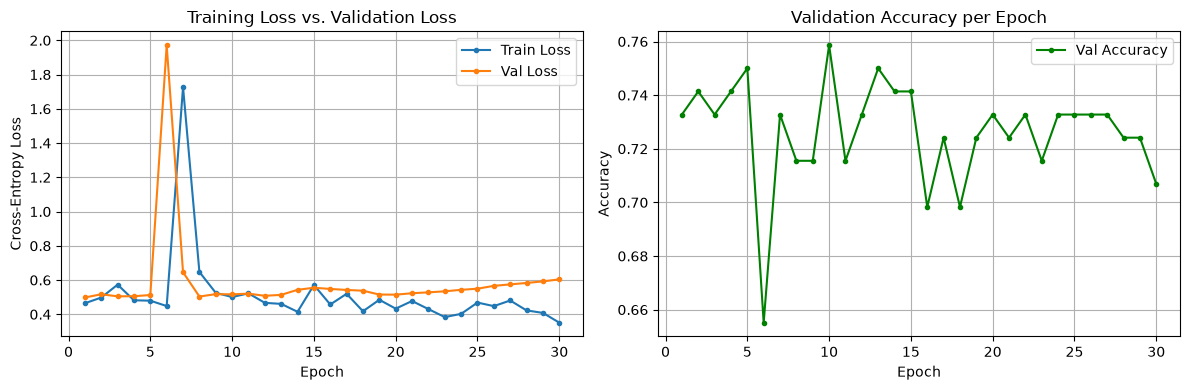

In [7]:
clf_finetuned.plot_history()

In [8]:
print(f"Vanilla     TabPFN v3 test acc: {(clf_vanilla.predict(X_test) == y_test).mean():.4f}")
print(f"Fine-tuned  TabPFN v3 test acc: {(clf_finetuned.predict(X_test) == y_test).mean():.4f}")

Vanilla     TabPFN v3 test acc: 0.7708
Fine-tuned  TabPFN v3 test acc: 0.7500


## 6. Side-by-side decision boundary comparison (PCA projection)

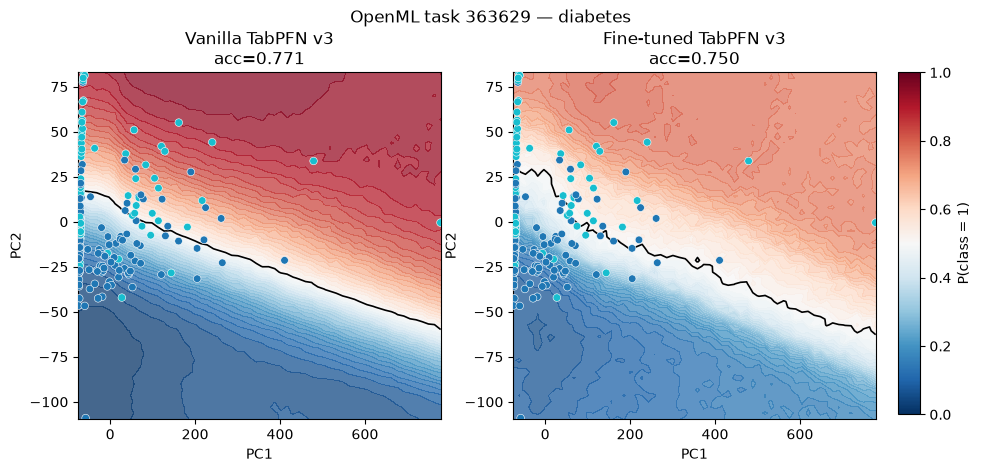

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

plot_decision_boundary_pca(clf_vanilla,   X_test, y_test, axes[0], "Vanilla TabPFN v3")
plot_decision_boundary_pca(clf_finetuned, X_test, y_test, axes[1], "Fine-tuned TabPFN v3")

n_classes = len(le.classes_)
if n_classes == 2:
    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=mcolors.Normalize(vmin=0, vmax=1))
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.87, 0.12, 0.02, 0.76])
    fig.colorbar(sm, cax=cbar_ax, label="P(class = 1)")
else:
    fig.tight_layout()

fig.suptitle(f"OpenML task {TASK_ID} — {dataset.name}", y=1.02)
plt.show()